## Questão 01

100%|██████████| 10000/10000 [00:33<00:00, 297.53it/s]


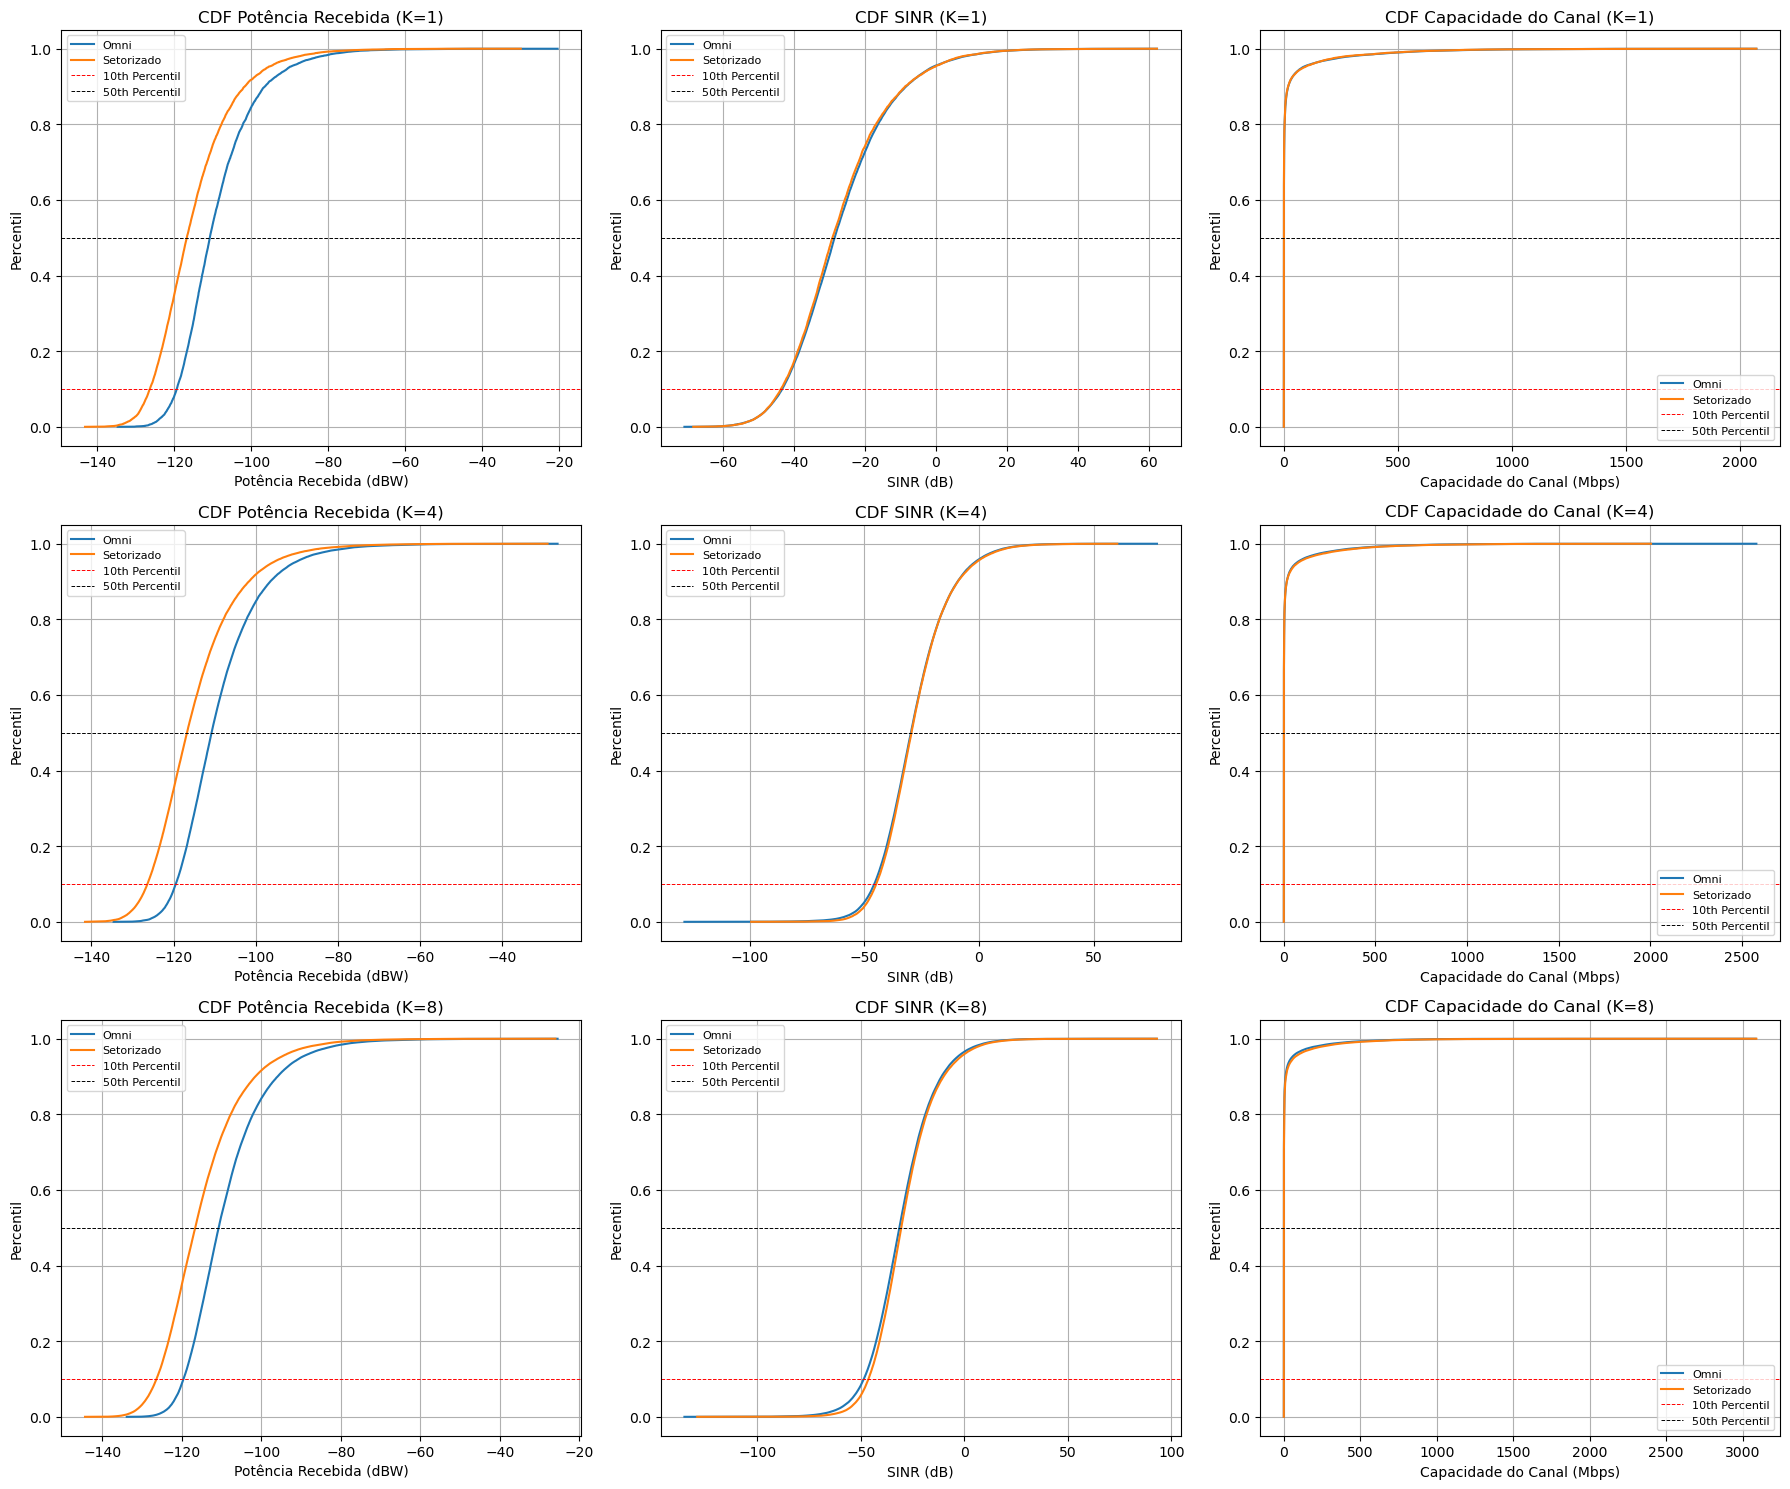

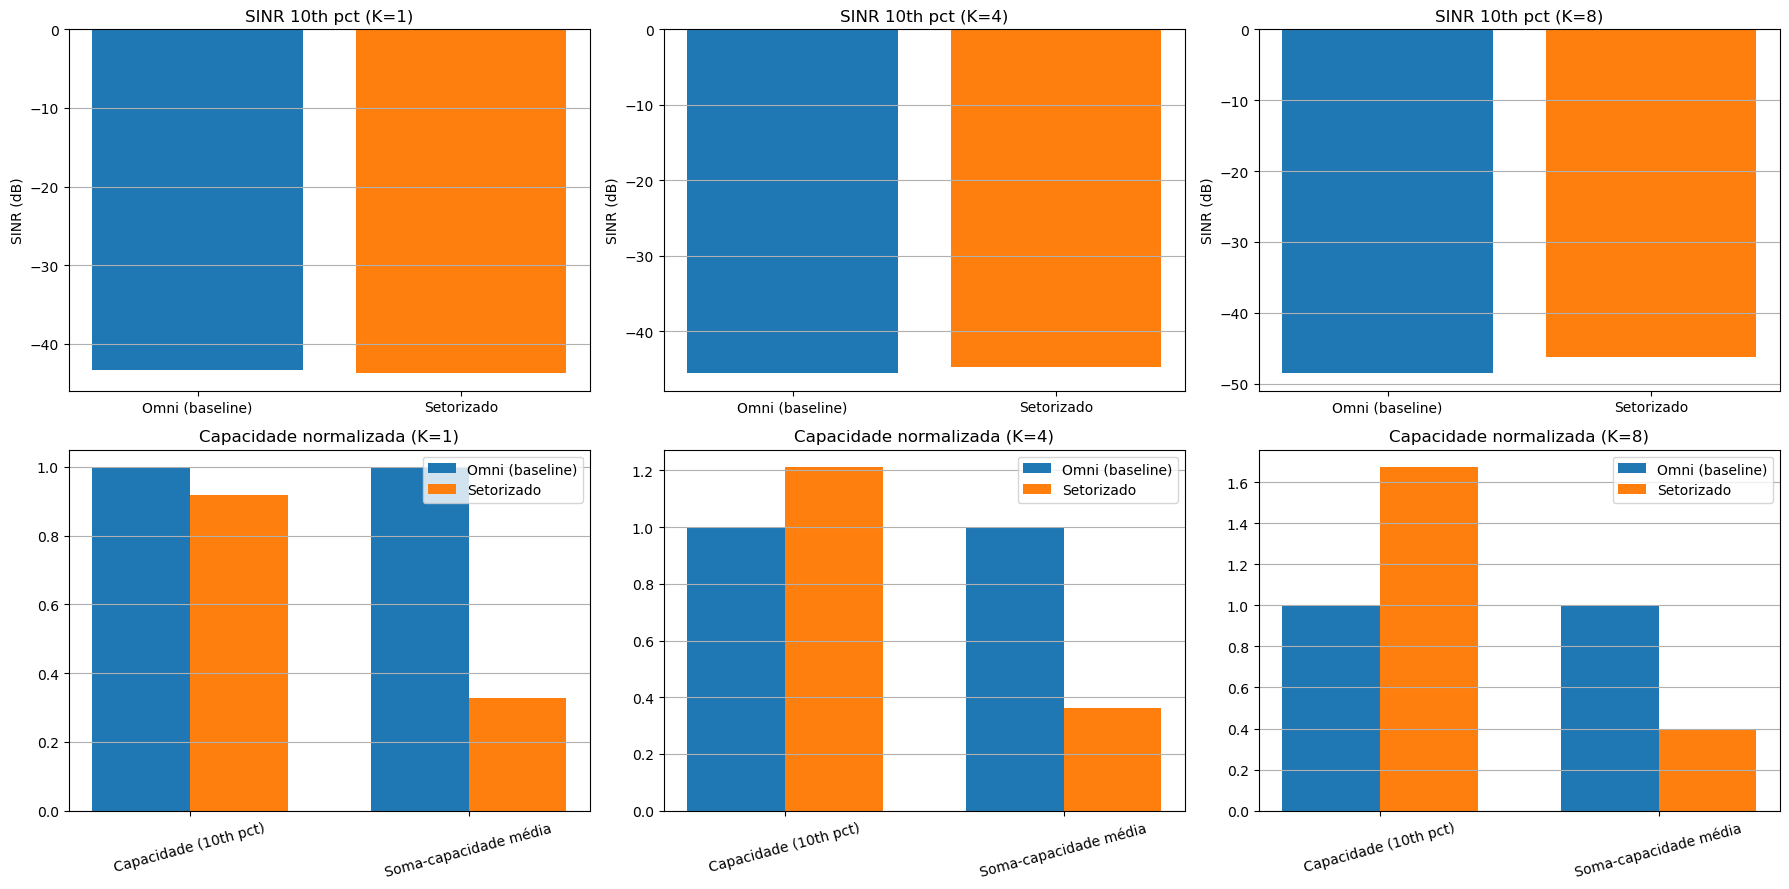

In [22]:
import sys
import importlib
import functions as f
importlib.reload(f)

M, N, sim = 16, 1, 10000
load_scenarios = {'K=1': 1, 'K=4': 4, 'K=8': 8}

resultados_por_carga = {'omni': {}, 'sector': {}}

for load_label, K in load_scenarios.items():
    # Uma única chamada roda 'omni' e 'sector' com os MESMOS UEs e
    # o MESMO shadowing em cada rodada de Monte Carlo -> comparação justa.
    res = f.simular_experimento(M=M, N=N, K=K, sim=sim,
                                 antenna_models=('omni', 'sector'))
    resultados_por_carga['omni'][load_label] = res['omni']
    resultados_por_carga['sector'][load_label] = res['sector']

# Passo 9: CDFs de potência recebida, SINR e capacidade (omni vs setor)
f.plot_all_cdfs(resultados_por_carga, load_labels=list(load_scenarios.keys()))

# Passo 10 / Remark 2: comparação normalizada de KPIs (percentil 10, soma-capacidade)
f.compare_kpis(resultados_por_carga, load_labels=list(load_scenarios.keys()))